# 2do Desafío Edición 2026 - Notebook Base

## Datos Disponibles para el Modelado

> Conviene hacer una copia en la cuenta del Drive, para evitar *rates limites* por acceso masivo al mismo archivo.

In [ ]:
import gdown
file_id = "1AnIEr3FGrlWHhDlR2KU8n522s1GaoQ-R"
output_file = "train.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)

!unzip -qq train.zip

Downloading...
From (original): https://drive.google.com/uc?id=1AnIEr3FGrlWHhDlR2KU8n522s1GaoQ-R
From (redirected): https://drive.google.com/uc?id=1AnIEr3FGrlWHhDlR2KU8n522s1GaoQ-R&confirm=t&uuid=9aa89bba-a7a9-4dd4-924f-d422d33952a5
To: /content/train.zip
100%|██████████| 5.32G/5.32G [01:10<00:00, 75.7MB/s]


## Librerías

In [ ]:
# Básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D

# Sistema
import os

# Repetibilidad
seed = 27
np.random.seed(seed)
tf.random.set_seed(seed)

## Generadores

In [ ]:
def explora_dir(directory_name):
    '''
    Acepta el nombre de directorio como argumento e imprime el contenido de cada directorio secuencialmente.
    Imprime los subdirectorios y el número de imágenes presentes en cada uno.
    '''
    for dirpaths, dirnames, filenames in os.walk(directory_name):
        print(f"Existen {len(dirnames)} directorios y {len(filenames)} imágenes en '{dirpaths}'")

In [ ]:
dir_train = './train'
explora_dir(dir_train)

Existen 10 directorios y 0 imágenes en './train'
Existen 0 directorios y 613 imágenes en './train/Nasua_nasua'
Existen 0 directorios y 90 imágenes en './train/Aspidosperma_polyneuron'
Existen 0 directorios y 153 imágenes en './train/Ilex_paraguariensis'
Existen 0 directorios y 333 imágenes en './train/Dicksonia_sellowiana'
Existen 0 directorios y 724 imágenes en './train/Philodendron_bipinnatifidum'
Existen 0 directorios y 169 imágenes en './train/Phyllomedusa_distincta'
Existen 0 directorios y 672 imágenes en './train/Aechmea_distichantha'
Existen 0 directorios y 641 imágenes en './train/Pecari_tajacu'
Existen 0 directorios y 717 imágenes en './train/Harpia_harpyja'
Existen 0 directorios y 571 imágenes en './train/Caiman_latirostris'


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 256

train_generator = ImageDataGenerator(
                                    validation_split=0.3,   # Para discriminar 2 subsets: training y validation
                                    rescale=1./255,         # Se incorpora el normalizado básico
                                    )

train_data = train_generator.flow_from_directory(
                                                dir_train,
                                                class_mode = 'categorical',
                                                classes = ["Pecari_tajacu", "Nasua_nasua", "Harpia_harpyja",
                                                           "Caiman_latirostris", "Phyllomedusa_distincta",
                                                           "Aspidosperma_polyneuron", "Philodendron_bipinnatifidum",
                                                           "Dicksonia_sellowiana", "Aechmea_distichantha", "Ilex_paraguariensis"],
                                                subset = 'training',
                                                shuffle = True,
                                                batch_size = BATCH_SIZE,
                                                target_size = IMAGE_SIZE)

val_data = train_generator.flow_from_directory(
                                                dir_train,
                                                class_mode = 'categorical',
                                                classes = ["Pecari_tajacu", "Nasua_nasua", "Harpia_harpyja",
                                                           "Caiman_latirostris", "Phyllomedusa_distincta",
                                                           "Aspidosperma_polyneuron", "Philodendron_bipinnatifidum",
                                                           "Dicksonia_sellowiana", "Aechmea_distichantha", "Ilex_paraguariensis"],
                                                subset = 'validation',
                                                shuffle = True,
                                                batch_size = BATCH_SIZE,
                                                target_size = IMAGE_SIZE)

Found 3283 images belonging to 10 classes.
Found 1400 images belonging to 10 classes.


In [ ]:
class_names = list(train_data.class_indices.keys())  # Para utilizar en la decodificación, gráficas, lo que corresponda
num_classes = len(class_names)

## Modelo Base

In [ ]:
def create_model_check_point_callback(checkpoint_path, monitor='val_loss'):
    """
    Toma el camino donde guardar los mejores pesos del modelo obtenidos durante el entrenamiento.
    """
    model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        monitor=monitor,
        filepath=checkpoint_path,
        save_best_only=True,
        save_weights_only=False,
        save_freq='epoch',
        verbose=1
    )
    return model_checkpoint_cb

ModelCheckPoint = create_model_check_point_callback('./CheckPoints/model.keras')

In [ ]:
from keras.models import Model
from keras.applications import MobileNetV2

# Traemos un modelo entrenado desde Keras
mobileNetV2 = MobileNetV2(
                      input_shape=(224, 224, 3),
                      include_top=False,
                      weights="imagenet",
                      )

mobileNetV2.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
modelo = Sequential()
modelo.add(mobileNetV2)
modelo.add(GlobalAveragePooling2D())
modelo.add(Dense(num_classes, activation='softmax'))

modelo.compile(optimizer='adam', loss=keras.losses.categorical_crossentropy, metrics=['accuracy'])

In [ ]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Aprox. 15 minutos con GPU

history = modelo.fit(train_data,
                     epochs=7,
                     batch_size=512,
                     validation_data=val_data,
                     callbacks=[ModelCheckPoint],
                     )

Epoch 1/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2491 - loss: 2.1238
Epoch 1: val_loss improved from None to 1.14663, saving model to ./CheckPoints/model.keras

Epoch 1: finished saving model to ./CheckPoints/model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 203s 13s/step - accuracy: 0.3884 - loss: 1.7655 - val_accuracy: 0.6464 - val_loss: 1.1466
Epoch 2/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6861 - loss: 1.0066
Epoch 2: val_loss improved from 1.14663 to 0.75637, saving model to ./CheckPoints/model.keras

Epoch 2: finished saving model to ./CheckPoints/model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 122s 10s/step - accuracy: 0.7243 - loss: 0.9028 - val_accuracy: 0.7564 - val_loss: 0.7564
Epoch 3/7
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8061 - loss: 0.6508
Epoch 3: val_loss improved from 0.75637 to 0.63913, saving model to ./CheckPoints/model.keras

Epoch 3: finished saving model to ./CheckPoints/model.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 111s 9s/step - accuracy: 0.7999

## Evaluación de Resultados

In [ ]:
modelo.load_weights('./CheckPoints/model.keras')

In [ ]:
# Evaluación sobre UN lote para validación
image_batch, label_batch = next(val_data)
predictions = modelo.predict_on_batch(image_batch)

y_pred = []
for i in predictions:
    class_prediction = np.argmax(i)
    y_pred.append(class_prediction)

y_true = []
for i in label_batch:
    label = np.argmax(i)
    y_true.append(label)

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79        37
           1       0.86      0.86      0.86        37
           2       0.94      0.88      0.91        33
           3       0.77      0.77      0.77        26
           4       0.81      0.93      0.87        14
           5       1.00      0.67      0.80         3
           6       0.84      0.86      0.85        43
           7       0.81      0.96      0.88        23
           8       0.90      0.84      0.87        32
           9       1.00      0.88      0.93         8

    accuracy                           0.85       256
   macro avg       0.87      0.84      0.85       256
weighted avg       0.85      0.85      0.85       256



In [ ]:
confusion_matrix(y_true, y_pred)

array([[29,  4,  0,  3,  0,  0,  1,  0,  0,  0],
       [ 3, 32,  1,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0, 29,  2,  1,  0,  1,  0,  0,  0],
       [ 2,  1,  1, 20,  1,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0, 13,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  2,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  1,  0, 37,  3,  2,  0],
       [ 0,  0,  0,  0,  0,  0,  1, 22,  0,  0],
       [ 2,  0,  0,  0,  0,  0,  3,  0, 27,  0],
       [ 0,  0,  0,  1,  0,  0,  0,  0,  0,  7]])

## Métrica de la Competencia

In [ ]:
def costo_personalizado(y_true, y_pred):
    """
    Calcula el costo promedio de clasificación según penalizaciones basadas en el dominio.

    Penalización aplicada:
        - Costo 0: si la clase predicha coincide con la real.
        - Costo 2: si la clase es incorrecta pero pertenece al mismo dominio (Animalia o Plantae).
        - Costo 5: si la clase es incorrecta y pertenece a un dominio diferente.

    Args:
        y_true (array-like): Lista o array de etiquetas reales (enteros del 0 al 9).
        y_pred (array-like): Lista o array de etiquetas predichas (enteros del 0 al 9).

    Returns:
        float: Costo promedio total de las predicciones.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Definición del dominio de cada clase (Animalia: 0–4, Plantae: 5–9)
    dominios = {
        0: 'animal', 1: 'animal', 2: 'animal', 3: 'animal', 4: 'animal',
        5: 'planta', 6: 'planta', 7: 'planta', 8: 'planta', 9: 'planta'
    }

    costos = []
    for real, pred in zip(y_true, y_pred):
        if real == pred:
            costos.append(0)
        elif dominios[real] == dominios[pred]:
            costos.append(2)
        else:
            costos.append(5)

    return np.mean(costos)

In [ ]:
costo_personalizado(y_true, y_pred)

np.float64(0.40234375)

### Extra - Matriz de confusión ponderada

In [ ]:
def plot_confusion_cost_matrix_colored(y_true, y_pred, class_names=None):
    """
    Muestra la matriz de confusión con colores y anotaciones de costos personalizados.
    - Costos codificados por tipo de error:
        * Verde/Blanco: Correcto (Costo 0)
        * Amarillo: Mismo dominio (Costo 2)
        * Rojo: Distinto dominio (Costo 5)
    - Escala de intensidad en función de la cantidad de errores en la celda.

    Args:
        y_true (array-like): Etiquetas reales
        y_pred (array-like): Etiquetas predichas
        class_names (list, optional): Lista de nombres de clase. Si None, usa índices.

    Returns:
        float: costo promedio total
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    dominios = {
        0: 'animal', 1: 'animal', 2: 'animal', 3: 'animal', 4: 'animal',
        5: 'planta', 6: 'planta', 7: 'planta', 8: 'planta', 9: 'planta'
    }

    n_classes = 10
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    annotated = np.empty_like(cm, dtype='object')
    color_matrix = np.zeros((n_classes, n_classes, 3))  # RGB
    total_cost = 0
    total_samples = len(y_true)

    max_count = cm.max()

    for i in range(n_classes):
        for j in range(n_classes):
            count = cm[i, j]

            if i == j:
                cost = 0
                color = (0.9, 0.95, 0.9)  # muy claro (verde pálido)
            elif dominios[i] == dominios[j]:
                cost = 2
                # Escalar amarillo (1.0, 1.0, 0.5) según cantidad
                intensity = count / max_count if max_count > 0 else 0
                color = (1.0, 1.0, 0.5 * intensity + 0.5)
            else:
                cost = 5
                # Escalar rojo (1.0, 0.5, 0.5) según cantidad
                intensity = count / max_count if max_count > 0 else 0
                color = (1.0, 0.5 * (1 - intensity), 0.5 * (1 - intensity))

            total_cost += count * cost
            annotated[i, j] = f"{count}\n(C{cost})"
            color_matrix[i, j] = color

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(color_matrix, interpolation='nearest')

    # Ejes
    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names if class_names else range(n_classes), rotation=45)
    ax.set_yticklabels(class_names if class_names else range(n_classes))
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Etiqueta real')
    ax.set_title("Matriz de Confusión con Penalización por Dominio")

    # Anotaciones
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, annotated[i, j],
                    ha="center", va="center",
                    color="black", fontsize=10, weight='bold')

    plt.tight_layout()
    costo_promedio = total_cost / total_samples
    print(f"\nCosto promedio total: {costo_promedio:.3f} (rango: 0.0 - 5.0)")
    return costo_promedio


Costo promedio total: 0.402 (rango: 0.0 - 5.0)


np.float64(0.40234375)

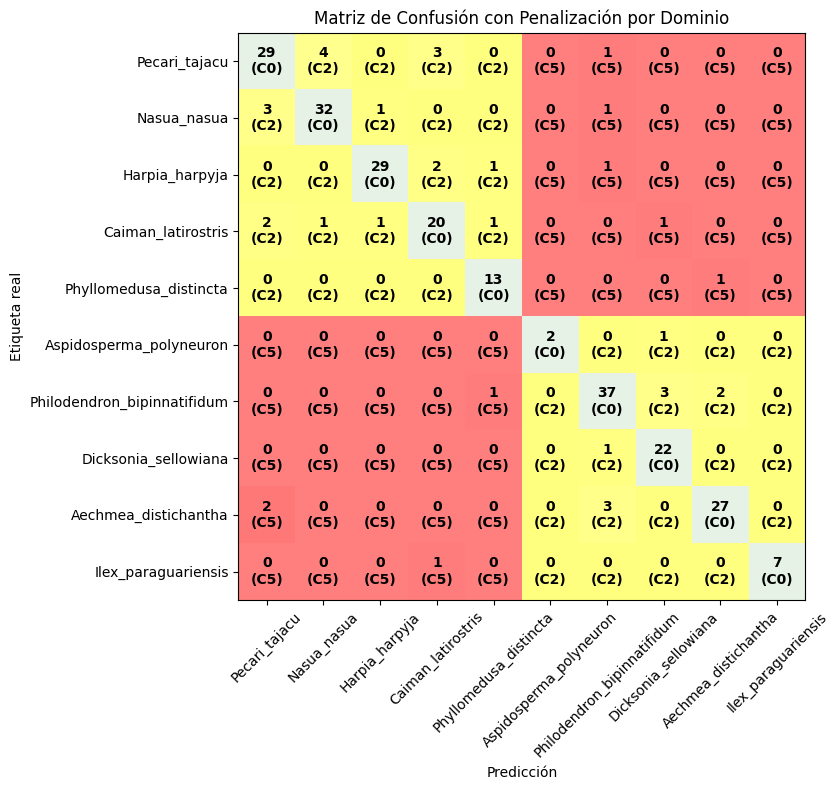

In [ ]:
plot_confusion_cost_matrix_colored(y_true, y_pred, class_names)

# Submit

## Descargar Datos

In [ ]:
import gdown
file_id = "1iTweDV68UfVz0z_6sSFUPapOcnpcsMKy"
output_file = "only_submit.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)

!unzip -qq only_submit.zip

Downloading...
From (original): https://drive.google.com/uc?id=1iTweDV68UfVz0z_6sSFUPapOcnpcsMKy
From (redirected): https://drive.google.com/uc?id=1iTweDV68UfVz0z_6sSFUPapOcnpcsMKy&confirm=t&uuid=af5bc8bd-79af-4ef8-b320-72999ba888e8
To: /content/only_submit.zip
100%|██████████| 413M/413M [00:05<00:00, 77.9MB/s]


## Generador

In [ ]:
only_test_generator = ImageDataGenerator(rescale=1./255)
only_test_data = only_test_generator.flow_from_directory(
                                                './only_submit',
                                                class_mode = None,          # No hay clases, todo está en el mismo directorio
                                                target_size = IMAGE_SIZE,
                                                batch_size = 64,            # Puede cambiarse según requerimiento de su modelo
                                                shuffle = False)

Found 391 images belonging to 1 classes.


## Predicción

In [ ]:
def generate_submit_file(model, only_test_data_generator, name_csv="submit_file"):
    only_test_data_generator.reset()

    ##### PREDICCIÓN DEL MODELO #####
    """
    En caso de realizar un pipeline diferente, sobrescribir este sector
    Para que todo resulte correcto, "predicted_class_indices" debe tener una predicción
    por imagen, de entre [0 a 9], correspondientes a las categorías del problema
    """
    predictions = model.predict(only_test_data_generator, verbose=1)
    predicted_class_indices = np.argmax(predictions, axis=1)
    #################################

    filenames = [os.path.basename(nombre) for nombre in only_test_data_generator.filenames]

    df = pd.DataFrame({'Image': filenames, 'Predict': predicted_class_indices})

    df.to_csv(f"{name_csv}.csv", index=False)
    print(f"Se generó el archivo '{name_csv}.csv' en el espacio de trabajo.")

In [ ]:
# Se realizan las predicciones de las imágenes en el directorio "only_submit"
# model -> debe ser un modelo válido de tensorflow. En caso de utilizar un pipeline especializado, editar la función

generate_submit_file(modelo, only_test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step
Se generó el archivo 'submit_file.csv' en el espacio de trabajo.
